In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from PIL import Image
import matplotlib.pyplot as plt

In [9]:
train_dir = "Dataset/train"
val_dir = "Dataset/validation"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)


Found 70295 images belonging to 38 classes.
Found 70295 images belonging to 38 classes.


In [10]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax') # Dynamic class count (38)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4141s 2s/step - accuracy: 0.8137 - loss: 0.6719 - val_accuracy: 0.9467 - val_loss: 0.1591
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3987s 2s/step - accuracy: 0.9486 - loss: 0.1520 - val_accuracy: 0.9611 - val_loss: 0.1133
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4393s 2s/step - accuracy: 0.9625 - loss: 0.1101 - val_accuracy: 0.9744 - val_loss: 0.0759
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 6270s 3s/step - accuracy: 0.9701 - loss: 0.0852 - val_accuracy: 0.9779 - val_loss: 0.0631
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4237s 2s/step - accuracy: 0.9786 - loss: 0.0636 - val_accuracy: 0.9758 - val_loss: 0.0673


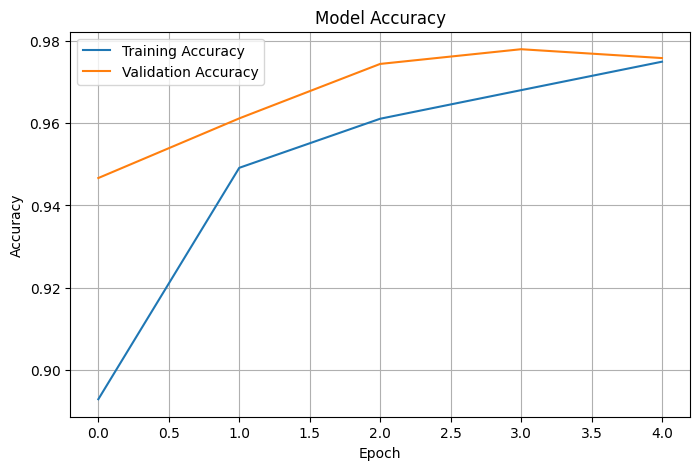

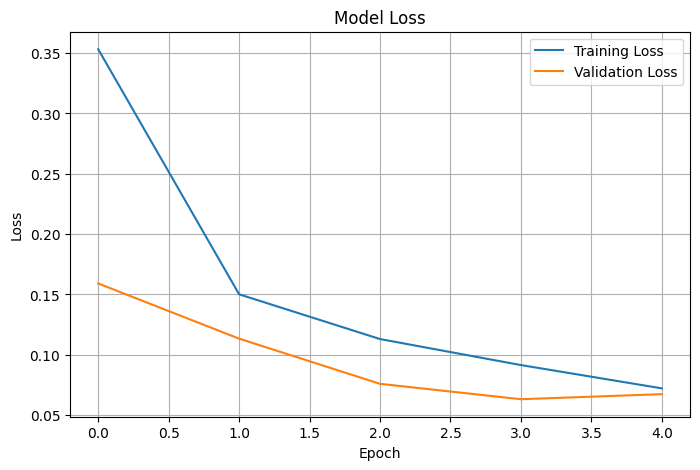

In [11]:
# Plot Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
data_cat = list(train_data.class_indices.keys())

# Updated dictionary mapping the PlantVillage folders to their Main Crop Category
subcategory_map = {
    "Apple___Apple_scab": "Apple", "Apple___Black_rot": "Apple", "Apple___Cedar_apple_rust": "Apple", "Apple___healthy": "Apple",
    "Blueberry___healthy": "Blueberry",
    "Cherry_(including_sour)___Powdery_mildew": "Cherry", "Cherry_(including_sour)___healthy": "Cherry",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Corn", "Corn_(maize)___Common_rust_": "Corn", "Corn_(maize)___Northern_Leaf_Blight": "Corn", "Corn_(maize)___healthy": "Corn",
    "Grape___Black_rot": "Grape", "Grape___Esca_(Black_Measles)": "Grape", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Grape", "Grape___healthy": "Grape",
    "Orange___Haunglongbing_(Citrus_greening)": "Orange",
    "Peach___Bacterial_spot": "Peach", "Peach___healthy": "Peach",
    "Pepper,_bell___Bacterial_spot": "Pepper", "Pepper,_bell___healthy": "Pepper",
    "Potato___Early_blight": "Potato", "Potato___Late_blight": "Potato", "Potato___healthy": "Potato",
    "Raspberry___healthy": "Raspberry", "Soybean___healthy": "Soybean", "Squash___Powdery_mildew": "Squash",
    "Strawberry___Leaf_scorch": "Strawberry", "Strawberry___healthy": "Strawberry",
    "Tomato___Bacterial_spot": "Tomato", "Tomato___Early_blight": "Tomato", "Tomato___Late_blight": "Tomato", "Tomato___Leaf_Mold": "Tomato", "Tomato___Septoria_leaf_spot": "Tomato", "Tomato___Spider_mites Two-spotted_spider_mite": "Tomato", "Tomato___Target_Spot": "Tomato", "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Tomato", "Tomato___Tomato_mosaic_virus": "Tomato", "Tomato___healthy": "Tomato"
}

In [13]:
def predict_image(image_path):
    image = Image.open(image_path).resize(IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(image) / 255.0
    img_array = np.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    class_index = np.argmax(predictions)
    confidence = predictions[0][class_index]
    predicted_label = data_cat[class_index]

    category = subcategory_map.get(predicted_label, "Unknown Plant")

    print("\n--- Detection Result ---")
    print("Main Plant Type:", category)
    print("Condition/Disease:", predicted_label.split("___")[-1].replace("_", " ")) # Cleans up label output text
    print(f"Confidence Score: {confidence * 100:.2f}%")

In [18]:
predict_image("C:/Users/M S I/Plant_Diseases_Dataset/Test_Images/Orange___Haunglongbing_(Citrus_greening).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step

--- Detection Result ---
Main Plant Type: Orange
Condition/Disease: Haunglongbing (Citrus greening)
Confidence Score: 100.00%


In [19]:
model.save('Plant_Disease_Classification.keras')
print("\nModel saved successfully as 'Plant_Disease_Classification.keras'")


Model saved successfully as 'Plant_Disease_Classification.keras'
